In [15]:
# Import library untuk manipulasi dan analisis data (Pandas)
import pandas as pd
# Import library untuk visualisasi data statistik (Seaborn)
import seaborn as sns  
# Import library untuk operasi matematika dan array (NumPy)
import numpy as np
# Import library dasar untuk membuat grafik/plot (Matplotlib)
import matplotlib.pyplot as plt
# Import library untuk perhitungan ilmiah/statistik tingkat lanjut (SciPy)
import scipy as sp
import scipy.stats as stats

# Membaca file CSV dari direktori kerja dan menyimpannya ke dalam DataFrame 'df'
df = pd.read_csv('ebay_mens_perfume.csv')

# Mengubah semua teks di kolom 'type' menjadi huruf kecil (lowercase)
# dan menghapus spasi tambahan di awal/akhir kata (strip)
# sehingga "Eau de Parfum", "EAU DE PARFUM", dan "Eau de Parfum " menjadi sama
df['type'] = df['type'].fillna('Unknown').str.lower().str.strip()

# Verifikasi: Melihat apakah sudah lebih rapi
print("Jumlah kategori unik setelah dibersihkan:", df['type'].nunique())

# Menampilkan 5 baris pertama dari DataFrame untuk melihat sekilas isi data
df.head()

Jumlah kategori unik setelah dibersihkan: 53


,brand,title,type,price,priceWithCurrency,available,availableText,sold,lastUpdated,itemLocation
0,Dior,Christian Dior Sauvage Men's EDP 3.4 oz Fragra...,eau de parfum,84.99,US $84.99/ea,10.0,More than 10 available / 116 sold,116.0,"May 24, 2024 10:03:04 PDT","Allen Park, Michigan, United States"
1,AS SHOW,A-v-entus Eau de Parfum 3.3 oz 100ML Millesime...,eau de parfum,109.99,US $109.99,8.0,8 available / 48 sold,48.0,"May 23, 2024 23:07:49 PDT","Atlanta, Georgia, Canada"
2,Unbranded,HOGO BOSS cologne For Men 3.4 oz,eau de toilette,100.00,US $100.00,10.0,More than 10 available / 27 sold,27.0,"May 22, 2024 21:55:43 PDT","Dearborn, Michigan, United States"
3,Giorgio Armani,Acqua Di Gio by Giorgio Armani 6.7 Fl oz Eau D...,eau de toilette,44.99,US $44.99/ea,2.0,2 available / 159 sold,159.0,"May 24, 2024 03:30:43 PDT","Reinholds, Pennsylvania, United States"
4,Lattafa,Lattafa Men's Hayaati Al Maleky EDP Spray 3.4 ...,fragrances,16.91,US $16.91,NaN,Limited quantity available / 156 sold,156.0,"May 24, 2024 07:56:25 PDT","Brooklyn, New York, United States"


In [16]:
# Menampilkan informasi ringkasan mengenai DataFrame 'df', 
# termasuk jumlah total baris (entries), daftar nama kolom, 
# jumlah data yang tidak kosong (non-null counts), 
# tipe data setiap kolom (dtypes), serta estimasi penggunaan memori.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand              999 non-null    object 
 1   title              1000 non-null   object 
 2   type               1000 non-null   object 
 3   price              1000 non-null   float64
 4   priceWithCurrency  1000 non-null   object 
 5   available          889 non-null    float64
 6   availableText      997 non-null    object 
 7   sold               994 non-null    float64
 8   lastUpdated        947 non-null    object 
 9   itemLocation       1000 non-null   object 
dtypes: float64(3), object(7)
memory usage: 78.3+ KB


In [17]:
# Menghitung dan mencetak jumlah data yang kosong (missing values/NaN) 
# pada kolom 'sold' menggunakan fungsi isnull() dan sum()
print(f"Data kosong di kolom sold: {df['sold'].isnull().sum()}")

# Mengisi seluruh nilai yang kosong pada kolom 'sold' dengan angka 0
# agar data bisa diolah secara matematis tanpa error
df['sold'] = df['sold'].fillna(0)

Data kosong di kolom sold: 6


In [18]:
# Melakukan pengelompokan data berdasarkan kolom 'brand' (merk), 
# kemudian menjumlahkan nilai pada kolom 'sold' (jumlah terjual) untuk setiap merk tersebut
top_brands = df.groupby('brand')['sold'].sum().sort_values(ascending=False).head(10)

# Menampilkan hasil (top 10 merk terlaris) ke layar console/notebook
print(top_brands)

brand
Calvin Klein     97572.0
Versace          96519.0
Davidoff         54944.0
Azzaro           38305.0
Armaf            24282.0
Kenneth Cole     23716.0
Paco Rabanne     21579.0
Liz Claiborne    21341.0
Burberry         19286.0
2nd To None      18882.0
Name: sold, dtype: float64


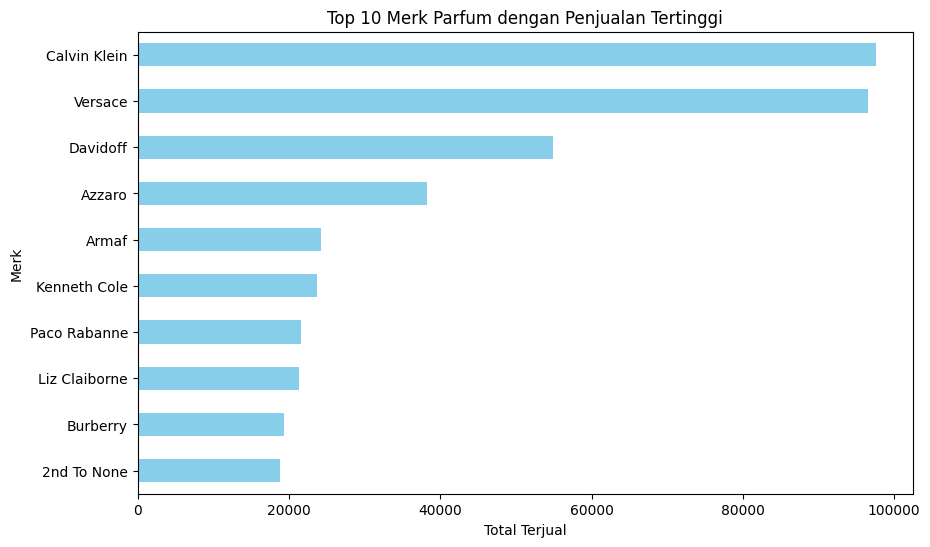

In [19]:
# Menentukan ukuran figure (lebar 10 inci, tinggi 6 inci) agar grafik tidak terlihat terlalu kecil atau gepeng
plt.figure(figsize=(10, 6))

# Membuat grafik batang horizontal (barh). 
# Kita mengurutkan secara 'ascending=True' agar merk dengan penjualan tertinggi berada di baris paling atas
top_brands.sort_values(ascending=True).plot(kind='barh', color='skyblue')

# Memberikan judul utama pada grafik
plt.title('Top 10 Merk Parfum dengan Penjualan Tertinggi')

# Memberikan label pada sumbu X (keterangan angka jumlah terjual)
plt.xlabel('Total Terjual')

# Memberikan label pada sumbu Y (keterangan nama merk)
plt.ylabel('Merk')

# Menampilkan grafik yang telah dibuat ke dalam notebook
plt.show()

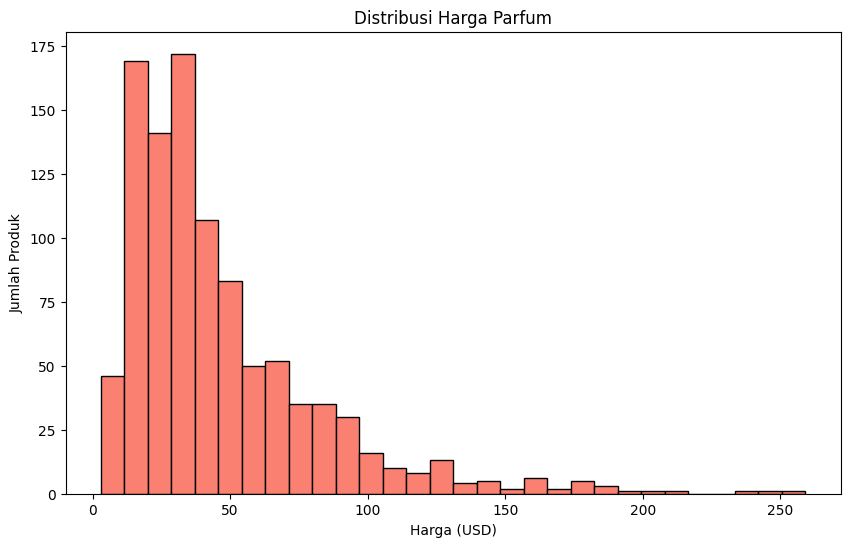

In [20]:
# Membuat figure untuk area grafik dengan ukuran 10x6 inci
plt.figure(figsize=(10, 6))

# Membuat histogram dari kolom 'price'.
# 'bins=30' membagi data harga ke dalam 30 kelompok rentang (batang).
# 'color' mengatur warna isi batang, dan 'edgecolor' memberikan garis tepi hitam agar antar batang terlihat jelas.
plt.hist(df['price'], bins=30, color='salmon', edgecolor='black')

# Memberikan judul pada grafik
plt.title('Distribusi Harga Parfum')

# Memberikan label pada sumbu X (Harga dalam USD)
plt.xlabel('Harga (USD)')

# Memberikan label pada sumbu Y (Jumlah produk/frekuensi)
plt.ylabel('Jumlah Produk')

# Menampilkan grafik histogram yang telah dibuat
plt.show()

type
EXTRAIT DE PARFUM        125.000000
Extrait de Parfum        125.000000
EDC                      110.190000
Eau De Parfum             92.846667
Eau de Toillette          92.000000
DIOR HOMME COLOGNE        89.990000
Elixir                    88.990000
Gift Sets                 78.833333
Eau de Parfum Intense     77.990000
Fragrance & Perfume       74.800000
Name: price, dtype: float64


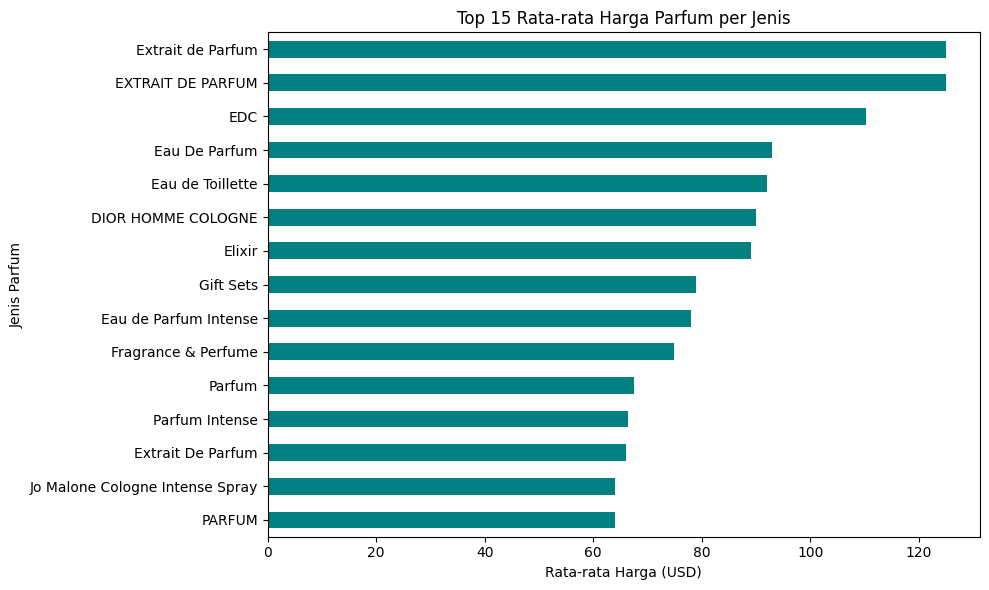

In [8]:
# Menghitung rata-rata harga berdasarkan jenis
avg_price_by_type = df.groupby('type')['price'].mean().sort_values(ascending=False)

# Menampilkan 10 teratas
print(avg_price_by_type.head(10))

# Visualisasi
plt.figure(figsize=(10, 6))
avg_price_by_type.head(15).sort_values().plot(kind='barh', color='teal')
plt.title('Top 15 Rata-rata Harga Parfum per Jenis')
plt.xlabel('Rata-rata Harga (USD)')
plt.ylabel('Jenis Parfum')
plt.tight_layout()
plt.show()

itemLocation
Dallas, Texas, United States             126
Hackensack, New Jersey, United States    105
Brooklyn, New York, United States         76
Miami, Florida, United States             41
Edison, New Jersey, United States         35
Houston, Texas, United States             28
Katy, Texas, United States                25
Detroit, Michigan, United States          22
New York, New York, United States         21
Warren, Michigan, United States           14
Name: count, dtype: int64


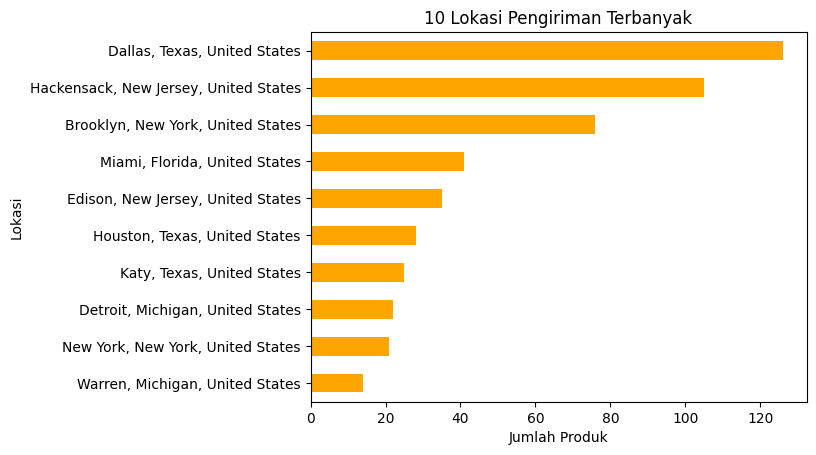

In [10]:
# Menghitung 10 lokasi pengiriman teratas
top_locations = df['itemLocation'].value_counts().head(10)

# Menampilkan hasilnya
print(top_locations)

# Visualisasi sederhana
top_locations.sort_values().plot(kind='barh', color='orange')
plt.title('10 Lokasi Pengiriman Terbanyak')
plt.xlabel('Jumlah Produk')
plt.ylabel('Lokasi')
plt.show()


In [11]:
df.copy()


,brand,title,type,price,priceWithCurrency,available,availableText,sold,lastUpdated,itemLocation
0,Dior,Christian Dior Sauvage Men's EDP 3.4 oz Fragra...,Eau de Parfum,84.99,US $84.99/ea,10.0,More than 10 available / 116 sold,116.0,"May 24, 2024 10:03:04 PDT","Allen Park, Michigan, United States"
1,AS SHOW,A-v-entus Eau de Parfum 3.3 oz 100ML Millesime...,Eau de Parfum,109.99,US $109.99,8.0,8 available / 48 sold,48.0,"May 23, 2024 23:07:49 PDT","Atlanta, Georgia, Canada"
2,Unbranded,HOGO BOSS cologne For Men 3.4 oz,Eau de Toilette,100.00,US $100.00,10.0,More than 10 available / 27 sold,27.0,"May 22, 2024 21:55:43 PDT","Dearborn, Michigan, United States"
3,Giorgio Armani,Acqua Di Gio by Giorgio Armani 6.7 Fl oz Eau D...,Eau de Toilette,44.99,US $44.99/ea,2.0,2 available / 159 sold,159.0,"May 24, 2024 03:30:43 PDT","Reinholds, Pennsylvania, United States"
4,Lattafa,Lattafa Men's Hayaati Al Maleky EDP Spray 3.4 ...,Fragrances,16.91,US $16.91,NaN,Limited quantity available / 156 sold,156.0,"May 24, 2024 07:56:25 PDT","Brooklyn, New York, United States"
...,...,...,...,...,...,...,...,...,...,...
995,GUESS,Guess 1981 by Guess cologne for men EDT 3.3 / ...,Eau de Toilette,20.28,US $20.28/ea,45.0,"45 available / 1,613 sold",1613.0,"May 24, 2024 08:14:07 PDT","Dallas, Texas, United States"
996,Armaf,Club de Nuit Intense by Armaf cologne for men ...,Eau de Toilette,30.58,US $30.58,10.0,More than 10 available / 31 sold,31.0,"May 23, 2024 08:39:30 PDT",United States
997,Paco Rabanne,Invictus by Paco Rabanne for Men EDT Spray 3.4...,Eau de Toilette,39.99,US $39.99/ea,2.0,2 available / 305 sold,305.0,"May 23, 2024 15:27:18 PDT","Jamaica, New York, United States"
998,Lomani,"Lomani EDT Cologne 3.4 oz Men - Authentic, Bra...",Eau de Toilette,9.99,US $9.99/ea,2.0,2 available / 22 sold,22.0,"May 20, 2024 13:20:54 PDT","Lincoln Park, Michigan, United States"


In [12]:
df.tail(10)

,brand,title,type,price,priceWithCurrency,available,availableText,sold,lastUpdated,itemLocation
990,Perry Ellis,"Perry Ellis 360 Red by Perry Ellis, 6.8 oz EDT...",Eau De Toilette,40.72,US $40.72/ea,10.0,More than 10 available / 232 sold,232.0,"May 24, 2024 07:58:54 PDT","Edison, New Jersey, United States"
991,Givenchy,Gentleman Boisee by Givenchy cologne for men E...,Eau de Parfum,73.52,US $73.52/ea,4.0,4 available / 8 sold,8.0,"May 08, 2024 06:01:12 PDT","Dallas, Texas, United States"
992,Mandarin Duck,Mandarina Duck Black 3.4oz EDT Spray For Men N...,Eau de Toilette,27.99,US $27.99/ea,10.0,More than 10 available / 75 sold,75.0,"Nov 02, 2022 03:03:01 PDT","Edison, New Jersey, United States"
993,Franck Olivier,Blue Touch By Franck Olivier Men Cologne 3.3oz...,Eau de Toilette,24.25,US $24.25,10.0,More than 10 available / 177 sold,177.0,"May 22, 2024 12:42:51 PDT","North Brunswick, New Jersey, United States"
994,Dolce&Gabbana,Dolce & Gabbana Cologne For Men Eau De Toilett...,Eau de Toilette,27.99,US $27.99/ea,7.0,7 available / 24 sold,24.0,NaN,"Des Moines, Iowa, United States"
995,GUESS,Guess 1981 by Guess cologne for men EDT 3.3 / ...,Eau de Toilette,20.28,US $20.28/ea,45.0,"45 available / 1,613 sold",1613.0,"May 24, 2024 08:14:07 PDT","Dallas, Texas, United States"
996,Armaf,Club de Nuit Intense by Armaf cologne for men ...,Eau de Toilette,30.58,US $30.58,10.0,More than 10 available / 31 sold,31.0,"May 23, 2024 08:39:30 PDT",United States
997,Paco Rabanne,Invictus by Paco Rabanne for Men EDT Spray 3.4...,Eau de Toilette,39.99,US $39.99/ea,2.0,2 available / 305 sold,305.0,"May 23, 2024 15:27:18 PDT","Jamaica, New York, United States"
998,Lomani,"Lomani EDT Cologne 3.4 oz Men - Authentic, Bra...",Eau de Toilette,9.99,US $9.99/ea,2.0,2 available / 22 sold,22.0,"May 20, 2024 13:20:54 PDT","Lincoln Park, Michigan, United States"
999,Estee Lauder,Beyond Paradise by Estee Lauder for Men Cologn...,Cologne spray,17.49,US $17.49/ea,10.0,More than 10 available / 24 sold,24.0,"Feb 28, 2024 07:27:01 PST","Keyport, New Jersey, United States"


In [13]:
#missing value
df.isnull().sum()

brand                  1
title                  0
type                   3
price                  0
priceWithCurrency      0
available            111
availableText          3
sold                   0
lastUpdated           53
itemLocation           0
dtype: int64